# Chapter 23 Python Lab  
## Stokes' Theorem and the Divergence Theorem

This lab accompanies **Chapter 23: Stokes' Theorem and the Divergence Theorem**.

The major theorems of vector calculus connect local derivative information with global integral information.

## Stokes' theorem

If $S$ is an oriented surface with positively oriented boundary curve $\partial S$, then

$$
\oint_{\partial S}\mathbf F\cdot d\mathbf r
=
\iint_S (\nabla\times\mathbf F)\cdot \mathbf n\,dS.
$$

Stokes' theorem says that **circulation around the boundary** equals **curl flux through the surface**.

## Divergence theorem

If $E$ is a solid region with outward-oriented closed boundary surface $\partial E$, then

$$
\iint_{\partial E}\mathbf F\cdot \mathbf n\,dS
=
\iiint_E \nabla\cdot\mathbf F\,dV.
$$

The divergence theorem says that **outward flux through the boundary** equals **total source strength inside**.

This lab uses Python to explore:

- circulation, curl, flux, and divergence;
- orientation conventions;
- Stokes' theorem on disks, tilted surfaces, and graph surfaces;
- the same boundary with different spanning surfaces;
- flux through closed surfaces;
- the divergence theorem for boxes, cylinders, spheres, and irregular solids;
- numerical surface and volume integration;
- and a mini-project that compares the two global vector calculus theorems.

Only `numpy` and `matplotlib` are required.

## Learning goals

By the end of this lab, you should be able to:

1. compute circulation around parametrized boundary curves;
2. compute curl flux through oriented parametrized surfaces;
3. verify Stokes' theorem numerically;
4. understand the boundary orientation induced by a surface normal;
5. compare different surfaces with the same boundary in Stokes' theorem;
6. compute outward flux through closed surfaces;
7. compute volume integrals of divergence;
8. verify the divergence theorem numerically;
9. recognize when a surface is open versus closed;
10. use sampled and grid-based computations to check vector calculus identities.

## Source note

This notebook was generated from the uploaded Chapter 23 QMD file.  
The extracted early headings from the source file include:

- Why this chapter matters
- Learning goals
- 23.1 The family of fundamental theorems
- 23.2 Orientation and boundary direction
- Arrows showing counterclockwise orientation
- 23.3 Stokes theorem
- 23.4 Example: circulation around a circle
- Direct calculation
- Stokes theorem calculation
- 23.5 Stokes theorem as a computational shortcut
- Example: replacing a tilted surface by a flat disk
- 23.6 Orientation signs in Stokes theorem
- 23.7 The Divergence theorem
- 23.8 Example: flux through a sphere

## 0. Setup

Run this cell first.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

np.set_printoptions(precision=6, suppress=True)
plt.rcParams["figure.max_open_warning"] = 120
norm = np.linalg.norm

def safe_eval_3d(f, X, Y, Z):
    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        W = f(X, Y, Z)
    return np.asarray(W, dtype=float)

def safe_eval_2d(f, X, Y):
    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        W = f(X, Y)
    return np.asarray(W, dtype=float)

def make_grid2d(xmin=-3, xmax=3, ymin=-3, ymax=3, n=250):
    x = np.linspace(xmin, xmax, n)
    y = np.linspace(ymin, ymax, n)
    X, Y = np.meshgrid(x, y)
    return x, y, X, Y

def make_3d_axes(title=None, elev=25, azim=45):
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    if title:
        ax.set_title(title)
    ax.view_init(elev=elev, azim=azim)
    return fig, ax

def line_integral_3d(F, r, rp, a, b, n=4000):
    t = np.linspace(a, b, n)
    X, Y, Z = r(t)
    dX, dY, dZ = rp(t)
    P, Q, R = F(X, Y, Z)
    integrand = P*dX + Q*dY + R*dZ
    return float(np.trapezoid(integrand, t)), t, X, Y, Z, integrand

def midpoint_rect_2d(integrand, umin, umax, vmin, vmax, nu=250, nv=250):
    du = (umax - umin)/nu
    dv = (vmax - vmin)/nv
    u = umin + (np.arange(nu) + 0.5)*du
    v = vmin + (np.arange(nv) + 0.5)*dv
    U, V = np.meshgrid(u, v)
    W = safe_eval_2d(integrand, U, V)
    return float(np.sum(W)*du*dv), U, V, W

def stack3(A, B, C):
    return np.stack([A, B, C], axis=-1)

def param_surface_flux(F, param, ru, rv, umin, umax, vmin, vmax, nu=250, nv=250):
    def integrand(U, V):
        X, Y, Z = param(U, V)
        Ru = stack3(*ru(U, V))
        Rv = stack3(*rv(U, V))
        cross = np.cross(Ru, Rv, axis=-1)
        P, Q, R = F(X, Y, Z)
        return P*cross[...,0] + Q*cross[...,1] + R*cross[...,2]
    return midpoint_rect_2d(integrand, umin, umax, vmin, vmax, nu=nu, nv=nv)

def param_surface_scalar_integral(f, param, ru, rv, umin, umax, vmin, vmax, nu=250, nv=250):
    def integrand(U, V):
        X, Y, Z = param(U, V)
        Ru = stack3(*ru(U, V))
        Rv = stack3(*rv(U, V))
        cross = np.cross(Ru, Rv, axis=-1)
        dS = np.sqrt(np.sum(cross**2, axis=-1))
        return safe_eval_3d(f, X, Y, Z)*dS
    return midpoint_rect_2d(integrand, umin, umax, vmin, vmax, nu=nu, nv=nv)

def graph_flux_upward(F, g, gx, gy, xmin, xmax, ymin, ymax, nx=300, ny=300):
    def integrand(X, Y):
        Z = g(X, Y)
        P, Q, R = F(X, Y, Z)
        return P*(-gx(X, Y)) + Q*(-gy(X, Y)) + R
    return midpoint_rect_2d(integrand, xmin, xmax, ymin, ymax, nu=nx, nv=ny)

def graph_scalar_surface_integral(f, g, gx, gy, xmin, xmax, ymin, ymax, nx=300, ny=300):
    def integrand(X, Y):
        Z = g(X, Y)
        dS = np.sqrt(1 + gx(X, Y)**2 + gy(X, Y)**2)
        return safe_eval_3d(f, X, Y, Z)*dS
    return midpoint_rect_2d(integrand, xmin, xmax, ymin, ymax, nu=nx, nv=ny)

def finite_partial_3d_component(g, X, Y, Z, var="x", h=1e-5):
    if var == "x":
        return (g(X+h, Y, Z) - g(X-h, Y, Z))/(2*h)
    if var == "y":
        return (g(X, Y+h, Z) - g(X, Y-h, Z))/(2*h)
    if var == "z":
        return (g(X, Y, Z+h) - g(X, Y, Z-h))/(2*h)
    raise ValueError("var must be x, y, or z.")

def numerical_divergence_3d(F, X, Y, Z, h=1e-5):
    P = lambda x, y, z: F(x, y, z)[0]
    Q = lambda x, y, z: F(x, y, z)[1]
    R = lambda x, y, z: F(x, y, z)[2]
    return (
        finite_partial_3d_component(P, X, Y, Z, "x", h=h)
        + finite_partial_3d_component(Q, X, Y, Z, "y", h=h)
        + finite_partial_3d_component(R, X, Y, Z, "z", h=h)
    )

def numerical_curl_3d(F, X, Y, Z, h=1e-5):
    P = lambda x, y, z: F(x, y, z)[0]
    Q = lambda x, y, z: F(x, y, z)[1]
    R = lambda x, y, z: F(x, y, z)[2]
    curl_x = finite_partial_3d_component(R, X, Y, Z, "y", h=h) - finite_partial_3d_component(Q, X, Y, Z, "z", h=h)
    curl_y = finite_partial_3d_component(P, X, Y, Z, "z", h=h) - finite_partial_3d_component(R, X, Y, Z, "x", h=h)
    curl_z = finite_partial_3d_component(Q, X, Y, Z, "x", h=h) - finite_partial_3d_component(P, X, Y, Z, "y", h=h)
    return curl_x, curl_y, curl_z

def plot_param_surface(param, umin, umax, vmin, vmax, nu=80, nv=80,
                       title="Parametrized surface", elev=25, azim=45, alpha=0.75):
    u = np.linspace(umin, umax, nu)
    v = np.linspace(vmin, vmax, nv)
    U, V = np.meshgrid(u, v)
    X, Y, Z = param(U, V)
    fig, ax = make_3d_axes(title=title, elev=elev, azim=azim)
    ax.plot_surface(X, Y, Z, linewidth=0, alpha=alpha)
    plt.show()
    return X, Y, Z

def plot_curve_3d(r, a, b, n=600, title="Boundary curve", elev=25, azim=45):
    t = np.linspace(a, b, n)
    X, Y, Z = r(t)
    fig, ax = make_3d_axes(title=title, elev=elev, azim=azim)
    ax.plot(X, Y, Z, linewidth=3)
    ax.scatter([X[0]], [Y[0]], [Z[0]], s=60, label="start")
    ax.scatter([X[-1]], [Y[-1]], [Z[-1]], s=60, label="end")
    ax.legend()
    plt.show()
    return np.column_stack([X, Y, Z])

def plot_surface_and_boundary(param, r_boundary, umin, umax, vmin, vmax,
                              a=0, b=2*np.pi, title="Surface and boundary",
                              elev=25, azim=45):
    u = np.linspace(umin, umax, 80)
    v = np.linspace(vmin, vmax, 80)
    U, V = np.meshgrid(u, v)
    X, Y, Z = param(U, V)
    t = np.linspace(a, b, 700)
    Xb, Yb, Zb = r_boundary(t)
    fig, ax = make_3d_axes(title=title, elev=elev, azim=azim)
    ax.plot_surface(X, Y, Z, linewidth=0, alpha=0.55)
    ax.plot(Xb, Yb, Zb, linewidth=4)
    plt.show()

def volume_integral_box(g, xmin, xmax, ymin, ymax, zmin, zmax, nx=90, ny=90, nz=90):
    dx = (xmax-xmin)/nx
    dy = (ymax-ymin)/ny
    dz = (zmax-zmin)/nz
    x = xmin + (np.arange(nx)+0.5)*dx
    y = ymin + (np.arange(ny)+0.5)*dy
    z = zmin + (np.arange(nz)+0.5)*dz
    X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
    W = safe_eval_3d(g, X, Y, Z)
    return float(np.sum(W)*dx*dy*dz)

def volume_integral_mask(g, xmin, xmax, ymin, ymax, zmin, zmax, mask, nx=90, ny=90, nz=90):
    dx = (xmax-xmin)/nx
    dy = (ymax-ymin)/ny
    dz = (zmax-zmin)/nz
    x = xmin + (np.arange(nx)+0.5)*dx
    y = ymin + (np.arange(ny)+0.5)*dy
    z = zmin + (np.arange(nz)+0.5)*dz
    X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
    inside = mask(X, Y, Z)
    W = safe_eval_3d(g, X, Y, Z)
    return float(np.sum(W[inside])*dx*dy*dz), X, Y, Z, inside, W

def plot_vector_field_3d(F, xmin=-2, xmax=2, ymin=-2, ymax=2, zmin=-2, zmax=2,
                         n=6, normalize=True, title="3D vector field"):
    x = np.linspace(xmin, xmax, n)
    y = np.linspace(ymin, ymax, n)
    z = np.linspace(zmin, zmax, n)
    X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
    U, V, W = F(X, Y, Z)
    M = np.sqrt(U**2 + V**2 + W**2)
    if normalize:
        U, V, W = U/(M+1e-12), V/(M+1e-12), W/(M+1e-12)
    fig, ax = make_3d_axes(title=title, elev=22, azim=45)
    ax.quiver(X, Y, Z, U, V, W, length=0.28, normalize=False)
    plt.show()
    return X, Y, Z, U, V, W

def one3(X, Y, Z):
    return np.ones_like(np.asarray(X, dtype=float))

print("Setup complete.")

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-uf0uj1au because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Setup complete.


---

# Part I. The two global theorems

Stokes' theorem and the divergence theorem are higher-dimensional versions of the same theme:

> **A boundary integral equals an interior integral of a derivative.**

| Theorem | Boundary integral | Interior derivative |
|---|---|---|
| Green's theorem | line integral around plane curve | scalar curl or divergence over region |
| Stokes' theorem | circulation around space curve | curl flux through surface |
| Divergence theorem | flux through closed surface | divergence over solid |

This lab emphasizes computation, geometry, and orientation.

---

# Part II. Stokes' theorem on a flat disk

Let

$$
\mathbf F(x,y,z)=\langle -y,x,0\rangle.
$$

Then

$$
\nabla\times\mathbf F=\langle0,0,2\rangle.
$$

Let $S$ be the unit disk in the plane $z=0$, oriented upward.  
Its positively oriented boundary is the unit circle traversed counterclockwise:

$$
\mathbf r(t)=\langle\cos t,\sin t,0\rangle,\qquad 0\leq t\leq2\pi.
$$

Stokes' theorem predicts

$$
\oint_{\partial S}\mathbf F\cdot d\mathbf r
=
\iint_S \langle0,0,2\rangle\cdot\mathbf k\,dS
=
2\pi.
$$

In [2]:
def F_rotation_z(X, Y, Z):
    return -Y, X, 0*Z

def curl_F_rotation_z(X, Y, Z):
    return 0*X, 0*Y, 2*np.ones_like(X)

def r_unit_circle(t):
    return np.cos(t), np.sin(t), 0*t

def rp_unit_circle(t):
    return -np.sin(t), np.cos(t), 0*t

circ_circle, t, Xb, Yb, Zb, integrand = line_integral_3d(
    F_rotation_z, r_unit_circle, rp_unit_circle, 0, 2*np.pi, n=6000
)

print("Boundary circulation:", circ_circle)
print("Exact value:", 2*np.pi)

plt.figure(figsize=(7, 4))
plt.plot(t, integrand)
plt.xlabel("t")
plt.ylabel(r"$\mathbf F(\mathbf r(t))\cdot \mathbf r'(t)$")
plt.title("Stokes theorem boundary integrand")
plt.grid(True, alpha=0.25)
plt.show()

Boundary circulation: 6.283185307179586
Exact value: 6.283185307179586


ValueError: 
\mathbf F(\mathbf r(t))\cdot \mathbf r'(t)
^
ParseFatalException: Unknown symbol: \mathbf, found '\'  (at char 0), (line:1, col:1)

<Figure size 700x400 with 1 Axes>

## 1. Curl flux through the disk

Parametrize the disk by

$$
\mathbf R(u,v)=\langle u,v,0\rangle,\qquad u^2+v^2\leq1.
$$

For numerical integration, we use a square grid and mask the unit disk.

Curl flux through unit disk: 6.283297959183674
Boundary circulation: 6.283185307179586
Difference: -0.00011265200408772102


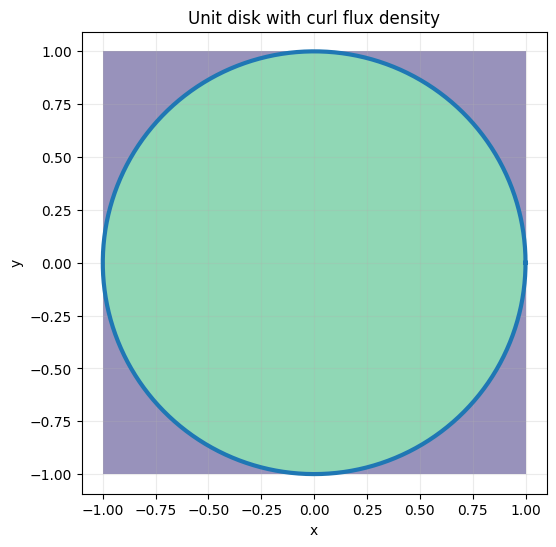

In [3]:
def curl_flux_disk_integrand(U, V):
    inside = U**2 + V**2 <= 1
    # upward normal is k, curl dot k = 2
    return np.where(inside, 2.0, 0.0)

curl_flux_disk, U, V, W = midpoint_rect_2d(
    curl_flux_disk_integrand,
    -1, 1, -1, 1,
    nu=700,
    nv=700
)

print("Curl flux through unit disk:", curl_flux_disk)
print("Boundary circulation:", circ_circle)
print("Difference:", circ_circle - curl_flux_disk)

plt.figure(figsize=(6, 6))
plt.contourf(U, V, W, levels=[-0.5,0.5,2.5], alpha=0.55)
theta = np.linspace(0, 2*np.pi, 700)
plt.plot(np.cos(theta), np.sin(theta), linewidth=3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Unit disk with curl flux density")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.show()

---

# Part III. Orientation in Stokes' theorem

If the surface normal is upward, the boundary orientation is counterclockwise when viewed from above.

If the surface normal is downward, the boundary orientation reverses.

Changing orientation changes the sign of both sides of Stokes' theorem.

In [4]:
def r_unit_circle_clockwise(t):
    return np.cos(-t), np.sin(-t), 0*t

def rp_unit_circle_clockwise(t):
    return np.sin(-t), -np.cos(-t), 0*t

circ_clockwise, *_ = line_integral_3d(
    F_rotation_z, r_unit_circle_clockwise, rp_unit_circle_clockwise, 0, 2*np.pi, n=6000
)

print("Counterclockwise circulation:", circ_circle)
print("Clockwise circulation:", circ_clockwise)
print("Sum:", circ_circle + circ_clockwise)
print("Downward oriented curl flux should be:", -curl_flux_disk)

Counterclockwise circulation: 6.283185307179586
Clockwise circulation: -6.283185307179586
Sum: 0.0
Downward oriented curl flux should be: -6.283297959183674


---

# Part IV. Same boundary, different spanning surfaces

Stokes' theorem says that for the same boundary curve, the curl flux is the same through any oriented surface spanning that boundary, provided orientation is consistent and the vector field is smooth.

We compare two surfaces with the same boundary:

1. flat disk $z=0$;
2. curved cap $z=1-r^2$ over the unit disk.

Both have the unit circle as boundary in the plane $z=0$.

## 2. Curved cap surface

Parametrize the cap by

$$
\mathbf R(r,\theta)=\langle r\cos\theta,r\sin\theta,1-r^2\rangle,
\qquad 0\leq r\leq1,\quad 0\leq\theta\leq2\pi.
$$

For this parameter order $(r,\theta)$, the normal has positive $z$ component, so the boundary orientation is counterclockwise viewed from above.

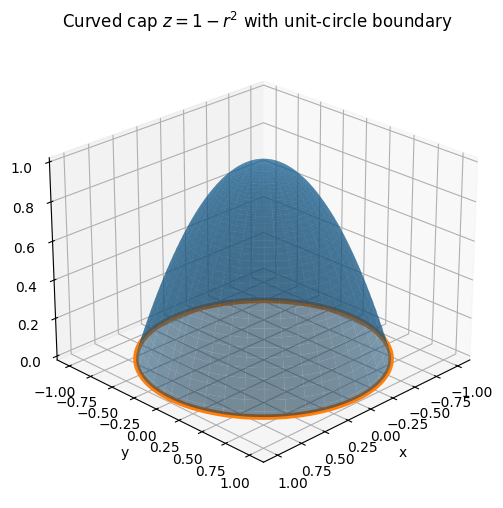

Curl flux through cap: 6.283185307179586
Boundary circulation: 6.283185307179586
Difference: 0.0


In [5]:
def cap_param(R, Theta):
    return R*np.cos(Theta), R*np.sin(Theta), 1 - R**2

def cap_r(R, Theta):
    return np.cos(Theta), np.sin(Theta), -2*R

def cap_theta(R, Theta):
    return -R*np.sin(Theta), R*np.cos(Theta), 0*R

def r_cap_boundary(t):
    return np.cos(t), np.sin(t), 0*t

plot_surface_and_boundary(
    cap_param,
    r_cap_boundary,
    0, 1,
    0, 2*np.pi,
    title=r"Curved cap $z=1-r^2$ with unit-circle boundary"
)

curl_flux_cap, *_ = param_surface_flux(
    curl_F_rotation_z,
    cap_param,
    cap_r,
    cap_theta,
    0, 1,
    0, 2*np.pi,
    nu=260,
    nv=360
)

print("Curl flux through cap:", curl_flux_cap)
print("Boundary circulation:", circ_circle)
print("Difference:", curl_flux_cap - circ_circle)

## 3. A nonconstant curl field

To see something less constant, use

$$
\mathbf F(x,y,z)=\langle -yz,xz,0\rangle.
$$

One computes

$$
\nabla\times\mathbf F=\langle -x,-y,2z\rangle.
$$

The unit circle in the plane $z=0$ gives zero circulation, because $\mathbf F=0$ on the boundary.  
Stokes' theorem predicts that the curl flux through the curved cap is also zero.

In [6]:
def F_variable_curl(X, Y, Z):
    return -Y*Z, X*Z, 0*Z

def curl_F_variable(X, Y, Z):
    return -X, -Y, 2*Z

circ_variable, *_ = line_integral_3d(
    F_variable_curl, r_unit_circle, rp_unit_circle, 0, 2*np.pi, n=6000
)

curl_flux_variable_cap, *_ = param_surface_flux(
    curl_F_variable,
    cap_param,
    cap_r,
    cap_theta,
    0, 1,
    0, 2*np.pi,
    nu=300,
    nv=420
)

print("Boundary circulation:", circ_variable)
print("Curl flux through cap:", curl_flux_variable_cap)
print("Difference:", circ_variable - curl_flux_variable_cap)

Boundary circulation: 0.0
Curl flux through cap: 3.490658503912069e-05
Difference: -3.490658503912069e-05


---

# Part V. Stokes' theorem on a tilted planar surface

Let $S$ be the triangle with vertices

$$
A=(0,0,0),\qquad B=(1,0,1),\qquad C=(0,1,1).
$$

Parametrize the triangle by

$$
\mathbf R(u,v)=A+u(B-A)+v(C-A),
\qquad u\geq0,\quad v\geq0,\quad u+v\leq1.
$$

Use the vector field

$$
\mathbf F(x,y,z)=\langle y,z,x\rangle.
$$

Then

$$
\nabla\times\mathbf F=\langle -1,-1,-1\rangle.
$$

In [7]:
A = np.array([0.0, 0.0, 0.0])
B = np.array([1.0, 0.0, 1.0])
C = np.array([0.0, 1.0, 1.0])

def F_yzx(X, Y, Z):
    return Y, Z, X

def curl_F_yzx(X, Y, Z):
    return -np.ones_like(X), -np.ones_like(Y), -np.ones_like(Z)

def tri_param(U, V):
    X = U
    Y = V
    Z = U + V
    return X, Y, Z

def tri_ru(U, V):
    return np.ones_like(U), 0*U, np.ones_like(U)

def tri_rv(U, V):
    return 0*V, np.ones_like(V), np.ones_like(V)

def triangle_mask(U, V):
    return (U >= 0) & (V >= 0) & (U + V <= 1)

def tri_flux_integrand(U, V):
    X, Y, Z = tri_param(U, V)
    Ru = stack3(*tri_ru(U, V))
    Rv = stack3(*tri_rv(U, V))
    cross = np.cross(Ru, Rv, axis=-1)
    P, Q, Rcomp = curl_F_yzx(X, Y, Z)
    val = P*cross[...,0] + Q*cross[...,1] + Rcomp*cross[...,2]
    return np.where(triangle_mask(U, V), val, 0.0)

curl_flux_triangle, U, V, W = midpoint_rect_2d(
    tri_flux_integrand,
    0, 1,
    0, 1,
    nu=500,
    nv=500
)

print("Curl flux through triangular surface:", curl_flux_triangle)

Curl flux through triangular surface: 0.501


## 4. Boundary circulation around the triangle

The orientation induced by $\mathbf R_u\times\mathbf R_v$ follows the boundary

$$
A\to B\to C\to A.
$$

Boundary segment contributions A->B, B->C, C->A: [0.5, 0.5, -0.5]
Total boundary circulation: 0.5
Curl flux through triangle: 0.501
Difference: -0.0010000000000000009


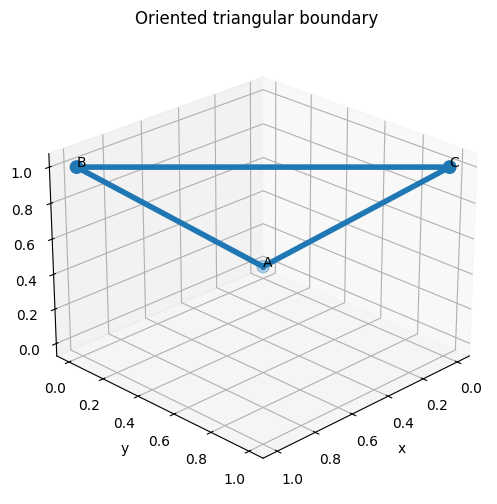

In [8]:
def line_segment_3d(P0, P1):
    P0 = np.asarray(P0, dtype=float)
    P1 = np.asarray(P1, dtype=float)
    d = P1 - P0
    def r(t):
        return P0[0] + t*d[0], P0[1] + t*d[1], P0[2] + t*d[2]
    def rp(t):
        return d[0]*np.ones_like(t), d[1]*np.ones_like(t), d[2]*np.ones_like(t)
    return r, rp

def piecewise_line_integral_3d(F, vertices, n_per_segment=2000):
    total = 0.0
    pieces = []
    for i in range(len(vertices)-1):
        r, rp = line_segment_3d(vertices[i], vertices[i+1])
        val, *_ = line_integral_3d(F, r, rp, 0, 1, n=n_per_segment)
        total += val
        pieces.append(val)
    return total, pieces

tri_vertices = [A, B, C, A]
circ_triangle, tri_pieces = piecewise_line_integral_3d(F_yzx, tri_vertices, n_per_segment=2000)

print("Boundary segment contributions A->B, B->C, C->A:", tri_pieces)
print("Total boundary circulation:", circ_triangle)
print("Curl flux through triangle:", curl_flux_triangle)
print("Difference:", circ_triangle - curl_flux_triangle)

fig, ax = make_3d_axes(title="Oriented triangular boundary", elev=25, azim=45)
tri = np.array(tri_vertices)
ax.plot(tri[:,0], tri[:,1], tri[:,2], linewidth=4)
ax.scatter(tri[:3,0], tri[:3,1], tri[:3,2], s=80)
for label, p in zip(["A", "B", "C"], [A, B, C]):
    ax.text(p[0], p[1], p[2], label)
plt.show()

---

# Part VI. Divergence theorem on a box

Let

$$
\mathbf F(x,y,z)=\langle x,y,z\rangle.
$$

Then

$$
\nabla\cdot\mathbf F=3.
$$

For the box

$$
0\leq x\leq a,\qquad 0\leq y\leq b,\qquad 0\leq z\leq c,
$$

the divergence theorem predicts

$$
\iint_{\partial E}\mathbf F\cdot\mathbf n\,dS
=
3abc.
$$

In [9]:
def F_radial3(X, Y, Z):
    return X, Y, Z

def div_F_radial3(X, Y, Z):
    return 3*np.ones_like(X)

a, b, c = 2.0, 1.5, 1.0

volume_div_box = volume_integral_box(
    div_F_radial3,
    0, a, 0, b, 0, c,
    nx=60, ny=60, nz=60
)

print("Volume integral of divergence:", volume_div_box)
print("Exact value:", 3*a*b*c)

Volume integral of divergence: 9.0
Exact value: 9.0


## 5. Compute box flux face by face

Only the outward-facing coordinate planes with $x=a$, $y=b$, and $z=c$ contribute, because $\mathbf F=\mathbf 0$ in the corresponding coordinate component on $x=0$, $y=0$, and $z=0$.

In [10]:
# x = a face, outward normal +i: flux integrand = x = a over area bc
flux_x_plus = a*b*c
# x = 0 face, outward normal -i: integrand = -x = 0
flux_x_minus = 0

# y = b face
flux_y_plus = b*a*c
flux_y_minus = 0

# z = c face
flux_z_plus = c*a*b
flux_z_minus = 0

box_flux_total = flux_x_plus + flux_x_minus + flux_y_plus + flux_y_minus + flux_z_plus + flux_z_minus

print("x-plus face flux:", flux_x_plus)
print("y-plus face flux:", flux_y_plus)
print("z-plus face flux:", flux_z_plus)
print("Total closed box flux:", box_flux_total)
print("Volume integral of divergence:", volume_div_box)

x-plus face flux: 3.0
y-plus face flux: 3.0
z-plus face flux: 3.0
Total closed box flux: 9.0
Volume integral of divergence: 9.0


---

# Part VII. Divergence theorem on a sphere

For

$$
\mathbf F=\langle x,y,z\rangle,
$$

and a sphere of radius $R$ oriented outward,

$$
\mathbf F\cdot\mathbf n=R,
$$

and the surface area is $4\pi R^2$.

Therefore the flux is

$$
4\pi R^3.
$$

The volume integral is

$$
\iiint_{\rho\leq R}3\,dV=3\cdot\frac{4}{3}\pi R^3=4\pi R^3.
$$

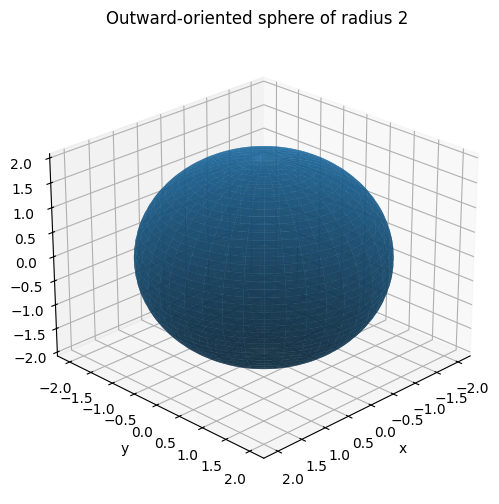

Surface flux through sphere: -100.53168265634649
Volume integral of divergence: 100.53096491487338
Difference: -201.06264757121988


In [11]:
R_sphere = 2.0

def sphere_param(Phi, Theta):
    return (
        R_sphere*np.sin(Phi)*np.cos(Theta),
        R_sphere*np.sin(Phi)*np.sin(Theta),
        R_sphere*np.cos(Phi)
    )

def sphere_rphi(Phi, Theta):
    return (
        R_sphere*np.cos(Phi)*np.cos(Theta),
        R_sphere*np.cos(Phi)*np.sin(Theta),
        -R_sphere*np.sin(Phi)
    )

def sphere_rtheta(Phi, Theta):
    return (
        -R_sphere*np.sin(Phi)*np.sin(Theta),
        R_sphere*np.sin(Phi)*np.cos(Theta),
        0*Theta
    )

# Outward orientation for this convention is r_theta x r_phi.
flux_sphere, *_ = param_surface_flux(
    F_radial3,
    sphere_param,
    sphere_rtheta,
    sphere_rphi,
    0, np.pi,
    0, 2*np.pi,
    nu=240,
    nv=300
)

volume_div_sphere = 3*(4*np.pi*R_sphere**3/3)

plot_param_surface(
    sphere_param,
    0, np.pi,
    0, 2*np.pi,
    nu=90,
    nv=120,
    title="Outward-oriented sphere of radius 2"
)

print("Surface flux through sphere:", flux_sphere)
print("Volume integral of divergence:", volume_div_sphere)
print("Difference:", flux_sphere - volume_div_sphere)

---

# Part VIII. Divergence theorem on a closed cylinder

Let

$$
E=\{x^2+y^2\leq R^2,\;0\leq z\leq h\}
$$

and

$$
\mathbf F=\langle x,y,z\rangle.
$$

The closed boundary consists of:

1. cylinder side;
2. top disk;
3. bottom disk.

The outward flux through all three pieces should equal

$$
\iiint_E 3\,dV=3\pi R^2h.
$$

In [12]:
R_cyl = 1.5
h_cyl = 2.5

def cyl_side_param(Theta, Z):
    return R_cyl*np.cos(Theta), R_cyl*np.sin(Theta), Z

def cyl_side_rtheta(Theta, Z):
    return -R_cyl*np.sin(Theta), R_cyl*np.cos(Theta), 0*Theta

def cyl_side_rz(Theta, Z):
    return 0*Z, 0*Z, np.ones_like(Z)

flux_side, *_ = param_surface_flux(
    F_radial3,
    cyl_side_param,
    cyl_side_rtheta,
    cyl_side_rz,
    0, 2*np.pi,
    0, h_cyl,
    nu=300,
    nv=180
)

def top_disk_param(r, theta):
    return r*np.cos(theta), r*np.sin(theta), h_cyl*np.ones_like(r)

def disk_rr(r, theta):
    return np.cos(theta), np.sin(theta), 0*r

def disk_rtheta(r, theta):
    return -r*np.sin(theta), r*np.cos(theta), 0*r

flux_top, *_ = param_surface_flux(
    F_radial3,
    top_disk_param,
    disk_rr,
    disk_rtheta,
    0, R_cyl,
    0, 2*np.pi,
    nu=220,
    nv=300
)

def bottom_disk_param(r, theta):
    return r*np.cos(theta), r*np.sin(theta), 0*r

# Use r_theta x r for downward outward normal on the bottom.
flux_bottom, *_ = param_surface_flux(
    F_radial3,
    bottom_disk_param,
    disk_rtheta,
    disk_rr,
    0, R_cyl,
    0, 2*np.pi,
    nu=220,
    nv=300
)

total_flux_cylinder = flux_side + flux_top + flux_bottom
volume_div_cylinder = 3*np.pi*R_cyl**2*h_cyl

print("Side flux:", flux_side)
print("Top flux:", flux_top)
print("Bottom flux:", flux_bottom)
print("Total closed-cylinder flux:", total_flux_cylinder)
print("Volume integral of divergence:", volume_div_cylinder)
print("Difference:", total_flux_cylinder - volume_div_cylinder)

Side flux: 35.342917352885166
Top flux: 17.671458676442583
Bottom flux: 0.0
Total closed-cylinder flux: 53.01437602932775
Volume integral of divergence: 53.01437602932776
Difference: -7.105427357601002e-15


---

# Part IX. Flux of a divergence-free field

A field with zero divergence has no net source strength.  
For a closed surface, the divergence theorem predicts zero total outward flux.

Let

$$
\mathbf F=\langle -y,x,0\rangle.
$$

Then

$$
\nabla\cdot\mathbf F=0.
$$

The total outward flux through any closed surface should be zero.

In [13]:
def div_zero(X, Y, Z):
    return 0*X

flux_sphere_rotation, *_ = param_surface_flux(
    F_rotation_z,
    sphere_param,
    sphere_rtheta,
    sphere_rphi,
    0, np.pi,
    0, 2*np.pi,
    nu=240,
    nv=300
)

print("Flux of rotational field through sphere:", flux_sphere_rotation)
print("Divergence theorem prediction:", 0.0)

Flux of rotational field through sphere: 6.543913317866101e-18
Divergence theorem prediction: 0.0


---

# Part X. Irregular solid check for the divergence theorem

Now define an irregular solid by a mask:

$$
E=\{(x,y,z):x^2+y^2+z^2\leq 1+0.15\sin(3x)\cos(2y)+0.1z\}.
$$

For a mask-defined solid, a direct boundary surface integral is difficult.  
But the divergence theorem lets us compute total flux if we can integrate divergence over the volume.

Use

$$
\mathbf F=\langle x^2,\;y^2,\;z^2\rangle.
$$

Then

$$
\nabla\cdot\mathbf F=2x+2y+2z.
$$

Estimated volume of irregular solid: 4.195071103999999
Divergence theorem prediction for total outward flux: 0.7544779468799987


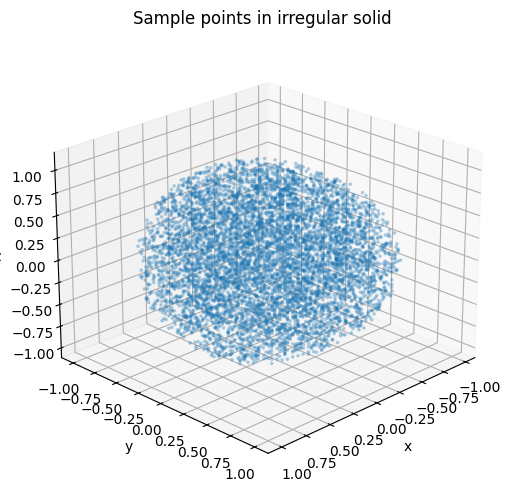

In [14]:
def F_square_components(X, Y, Z):
    return X**2, Y**2, Z**2

def div_F_square_components(X, Y, Z):
    return 2*X + 2*Y + 2*Z

def irregular_mask(X, Y, Z):
    boundary = 1 + 0.15*np.sin(3*X)*np.cos(2*Y) + 0.1*Z
    return X**2 + Y**2 + Z**2 <= boundary

vol_irreg, X, Y, Z, inside, W = volume_integral_mask(
    div_F_square_components,
    -1.4, 1.4,
    -1.4, 1.4,
    -1.4, 1.4,
    irregular_mask,
    nx=100,
    ny=100,
    nz=100
)

volume_irreg, *_ = volume_integral_mask(
    one3,
    -1.4, 1.4,
    -1.4, 1.4,
    -1.4, 1.4,
    irregular_mask,
    nx=100,
    ny=100,
    nz=100
)

print("Estimated volume of irregular solid:", volume_irreg)
print("Divergence theorem prediction for total outward flux:", vol_irreg)

# Visualize a random subset of points inside the solid.
rng = np.random.default_rng(23)
pts = np.column_stack([X[inside], Y[inside], Z[inside]])
idx = rng.choice(len(pts), size=min(7000, len(pts)), replace=False)

fig, ax = make_3d_axes(title="Sample points in irregular solid", elev=23, azim=45)
ax.scatter(pts[idx,0], pts[idx,1], pts[idx,2], s=3, alpha=0.25)
plt.show()

### Interpretation

The divergence theorem is especially useful here because we avoided constructing the complicated boundary surface.

---

# Part XI. Stokes' theorem as surface independence

If two oriented surfaces $S_1$ and $S_2$ have the same boundary orientation, then Stokes' theorem gives

$$
\iint_{S_1}(\nabla\times\mathbf F)\cdot \mathbf n\,dS
=
\oint_{\partial S}\mathbf F\cdot d\mathbf r
=
\iint_{S_2}(\nabla\times\mathbf F)\cdot \mathbf n\,dS.
$$

The curl flux depends only on the boundary, not the particular spanning surface.

## 6. Compare a flat disk and a wavy disk

Both surfaces have boundary the unit circle in the plane $z=0$.

Let

$$
z=g(x,y)=0.25(1-x^2-y^2)\sin(3x)\cos(2y)
$$

over the unit disk.  
This graph is zero on the unit circle.

In [15]:
def g_wavy_disk(X, Y):
    return 0.25*(1 - X**2 - Y**2)*np.sin(3*X)*np.cos(2*Y)

def gx_wavy_disk(X, Y):
    # derivative of 0.25(1-x^2-y^2) sin(3x) cos(2y)
    return 0.25*((-2*X)*np.sin(3*X)*np.cos(2*Y)
                 + (1-X**2-Y**2)*3*np.cos(3*X)*np.cos(2*Y))

def gy_wavy_disk(X, Y):
    return 0.25*((-2*Y)*np.sin(3*X)*np.cos(2*Y)
                 + (1-X**2-Y**2)*np.sin(3*X)*(-2*np.sin(2*Y)))

def wavy_graph_flux_curl_integrand(X, Y):
    Z = g_wavy_disk(X, Y)
    Cx, Cy, Cz = curl_F_rotation_z(X, Y, Z)
    return Cx*(-gx_wavy_disk(X, Y)) + Cy*(-gy_wavy_disk(X, Y)) + Cz

wavy_curl_flux, X2, Y2, W2 = midpoint_rect_2d(
    lambda X, Y: np.where(X**2+Y**2 <= 1, wavy_graph_flux_curl_integrand(X, Y), 0.0),
    -1, 1,
    -1, 1,
    nu=700,
    nv=700
)

print("Curl flux through flat disk:", curl_flux_disk)
print("Curl flux through wavy disk:", wavy_curl_flux)
print("Boundary circulation:", circ_circle)

Curl flux through flat disk: 6.283297959183674
Curl flux through wavy disk: 6.283297959183674
Boundary circulation: 6.283185307179586


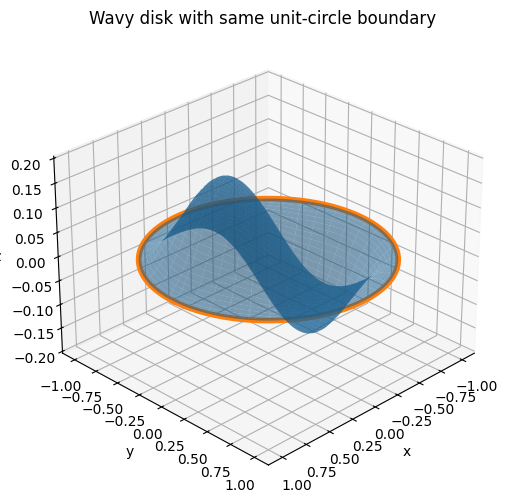

In [16]:
def wavy_disk_param_radial(R, Theta):
    X = R*np.cos(Theta)
    Y = R*np.sin(Theta)
    Z = g_wavy_disk(X, Y)
    return X, Y, Z

plot_surface_and_boundary(
    wavy_disk_param_radial,
    r_unit_circle,
    0, 1,
    0, 2*np.pi,
    title="Wavy disk with same unit-circle boundary",
    elev=28,
    azim=45
)

---

# Part XII. Numerical derivative identity checks

Two famous identities are:

$$
\nabla\cdot(\nabla\times\mathbf F)=0
$$

and

$$
\nabla\times(\nabla f)=\mathbf 0.
$$

These are differential versions of the idea that boundaries of boundaries cancel.

## 7. Check $\nabla\times(\nabla f)=0$

Let

$$
f(x,y,z)=x^2y+yz^2+\sin(xz).
$$

In [17]:
def grad_f_test(X, Y, Z):
    fx = 2*X*Y + Z*np.cos(X*Z)
    fy = X**2 + Z**2
    fz = 2*Y*Z + X*np.cos(X*Z)
    return fx, fy, fz

for p in [(0.2,0.5,-0.3), (1.0,-0.4,0.7), (-1.2,0.9,0.2)]:
    curl_grad = numerical_curl_3d(grad_f_test, *p)
    print("point:", p, "curl(grad f):", np.array(curl_grad))

point: (0.2, 0.5, -0.3) curl(grad f): [0. 0. 0.]
point: (1.0, -0.4, 0.7) curl(grad f): [ 0. -0.  0.]
point: (-1.2, 0.9, 0.2) curl(grad f): [ 0. -0. -0.]


## 8. Check $\nabla\cdot(\nabla\times\mathbf F)=0$

Use

$$
\mathbf F(x,y,z)=\langle xy,\;yz,\;zx\rangle.
$$

In [18]:
def F_test_identity(X, Y, Z):
    return X*Y, Y*Z, Z*X

def curl_F_test_identity(X, Y, Z):
    return -Y, -Z, -X

for p in [(0.2,0.5,-0.3), (1.0,-0.4,0.7), (-1.2,0.9,0.2)]:
    div_curl = numerical_divergence_3d(curl_F_test_identity, *p)
    print("point:", p, "div(curl F):", div_curl)

point: (0.2, 0.5, -0.3) div(curl F): 0.0
point: (1.0, -0.4, 0.7) div(curl F): 0.0
point: (-1.2, 0.9, 0.2) div(curl F): 0.0


---

# Part XIII. Chapter mini-project: Stokes versus divergence

In this mini-project, you will analyze the same vector field in two different ways.

Let

$$
\mathbf F(x,y,z)=\langle -y+xz,\;x+yz,\;z^2\rangle.
$$

Tasks:

1. compute $\nabla\times\mathbf F$ and use Stokes' theorem on the unit disk;
2. compute $\nabla\cdot\mathbf F$ and use the divergence theorem on the unit ball;
3. compare what each theorem measures;
4. interpret why circulation and outward flux are different geometric quantities.

## 9. Define the field and diagnostic quantities

In [19]:
def F_project(X, Y, Z):
    return -Y + X*Z, X + Y*Z, Z**2

# Analytic:
# P=-y+xz, Q=x+yz, R=z^2
# curl = <R_y-Q_z, P_z-R_x, Q_x-P_y> = <-y, x, 2>
# divergence = P_x+Q_y+R_z = z+z+2z = 4z.
def curl_F_project(X, Y, Z):
    return -Y, X, 2*np.ones_like(X)

def div_F_project(X, Y, Z):
    return 4*Z

probe = (0.5, -0.3, 0.8)
print("Numerical curl at probe:", np.array(numerical_curl_3d(F_project, *probe)))
print("Analytic curl at probe:", np.array(curl_F_project(*probe)))
print("Numerical divergence at probe:", numerical_divergence_3d(F_project, *probe))
print("Analytic divergence at probe:", div_F_project(*probe))

Numerical curl at probe: [0.3 0.5 2. ]
Analytic curl at probe: [0.3 0.5 2. ]
Numerical divergence at probe: 3.1999999999976487
Analytic divergence at probe: 3.2


## 10. Stokes theorem on the unit disk

For the unit disk in the plane $z=0$ oriented upward,

$$
(\nabla\times\mathbf F)\cdot\mathbf k=2.
$$

So the curl flux is $2\pi$.

In [20]:
stokes_boundary_project, *_ = line_integral_3d(F_project, r_unit_circle, rp_unit_circle, 0, 2*np.pi, n=6000)

stokes_curl_flux_project, *_ = midpoint_rect_2d(
    lambda X, Y: np.where(X**2+Y**2 <= 1, 2.0, 0.0),
    -1, 1, -1, 1,
    nu=700,
    nv=700
)

print("Boundary circulation:", stokes_boundary_project)
print("Curl flux through disk:", stokes_curl_flux_project)
print("Exact value:", 2*np.pi)

Boundary circulation: 6.283185307179586
Curl flux through disk: 6.283297959183674
Exact value: 6.283185307179586


## 11. Divergence theorem on the unit ball

For the unit ball,

$$
\nabla\cdot\mathbf F=4z.
$$

By symmetry,

$$
\iiint_{x^2+y^2+z^2\leq1}4z\,dV=0.
$$

So the total outward flux through the unit sphere is zero.

In [21]:
def unit_ball_mask(X, Y, Z):
    return X**2 + Y**2 + Z**2 <= 1

volume_div_project, *_ = volume_integral_mask(
    div_F_project,
    -1, 1,
    -1, 1,
    -1, 1,
    unit_ball_mask,
    nx=120,
    ny=120,
    nz=120
)

R_sphere = 1.0

def sphere_param_unit(Phi, Theta):
    return (
        np.sin(Phi)*np.cos(Theta),
        np.sin(Phi)*np.sin(Theta),
        np.cos(Phi)
    )

def sphere_rphi_unit(Phi, Theta):
    return (
        np.cos(Phi)*np.cos(Theta),
        np.cos(Phi)*np.sin(Theta),
        -np.sin(Phi)
    )

def sphere_rtheta_unit(Phi, Theta):
    return (
        -np.sin(Phi)*np.sin(Theta),
        np.sin(Phi)*np.cos(Theta),
        0*Theta
    )

sphere_flux_project, *_ = param_surface_flux(
    F_project,
    sphere_param_unit,
    sphere_rtheta_unit,
    sphere_rphi_unit,
    0, np.pi,
    0, 2*np.pi,
    nu=250,
    nv=320
)

print("Volume integral of divergence:", volume_div_project)
print("Surface flux through sphere:", sphere_flux_project)
print("Expected value by symmetry:", 0.0)

Volume integral of divergence: -2.2276830585960174e-16
Surface flux through sphere: 5.785539962416466e-17
Expected value by symmetry: 0.0


## 12. Mini-project questions

Answer the following in a markdown cell:

1. What does Stokes' theorem measure for this field on the unit disk?
2. What does the divergence theorem measure for this field on the unit ball?
3. Why can circulation be nonzero while total outward flux is zero?
4. Which theorem uses curl?
5. Which theorem uses divergence?
6. How does orientation affect the sign in each theorem?

In [22]:
print("Mini-project summary")
print("--------------------")
print("Stokes boundary circulation:", stokes_boundary_project)
print("Stokes curl flux:", stokes_curl_flux_project)
print("Divergence theorem volume integral:", volume_div_project)
print("Divergence theorem sphere flux:", sphere_flux_project)
print()
print("Interpretation:")
print("- Stokes measures circulation created by curl through an open surface.")
print("- Divergence theorem measures net outward flux created by sources inside a closed surface.")

Mini-project summary
--------------------
Stokes boundary circulation: 6.283185307179586
Stokes curl flux: 6.283297959183674
Divergence theorem volume integral: -2.2276830585960174e-16
Divergence theorem sphere flux: 5.785539962416466e-17

Interpretation:
- Stokes measures circulation created by curl through an open surface.
- Divergence theorem measures net outward flux created by sources inside a closed surface.


---

# Part XIV. Additional exercises with reference solutions

Try each exercise before running the reference solution.

## Exercise A. Stokes on a disk

Let

$$
\mathbf F=\langle -2y,2x,0\rangle.
$$

Use Stokes' theorem to compute the circulation around the circle $x^2+y^2=9$ in the plane $z=0$, oriented counterclockwise.

In [23]:
# Exercise A workspace

# Your code here

### Reference solution for Exercise A

In [24]:
def F_A(X, Y, Z):
    return -2*Y, 2*X, 0*Z

def r_circle3(t):
    return 3*np.cos(t), 3*np.sin(t), 0*t

def rp_circle3(t):
    return -3*np.sin(t), 3*np.cos(t), 0*t

IA, *_ = line_integral_3d(F_A, r_circle3, rp_circle3, 0, 2*np.pi, n=6000)

# Curl is <0,0,4>, disk area is 9π, so circulation is 36π.
print("Numerical circulation:", IA)
print("Stokes theorem value:", 36*np.pi)

Numerical circulation: 113.09733552923255
Stokes theorem value: 113.09733552923255


## Exercise B. Divergence theorem on a sphere

Let

$$
\mathbf F=\langle 3x,3y,3z\rangle.
$$

Compute the outward flux through the unit sphere.

In [25]:
# Exercise B workspace

# Your code here

### Reference solution for Exercise B

In [26]:
def F_B(X, Y, Z):
    return 3*X, 3*Y, 3*Z

IB, *_ = param_surface_flux(
    F_B,
    sphere_param_unit,
    sphere_rtheta_unit,
    sphere_rphi_unit,
    0, np.pi,
    0, 2*np.pi,
    nu=220,
    nv=280
)

# divergence = 9, volume of unit ball = 4π/3, flux = 12π.
print("Numerical sphere flux:", IB)
print("Divergence theorem value:", 12*np.pi)

Numerical sphere flux: -37.69943215775824
Divergence theorem value: 37.69911184307752


## Exercise C. Orientation reversal

For Exercise A, reverse the circle orientation. What happens to the circulation?

In [27]:
# Exercise C workspace

# Your code here

### Reference solution for Exercise C

In [28]:
def r_circle3_clockwise(t):
    return 3*np.cos(-t), 3*np.sin(-t), 0*t

def rp_circle3_clockwise(t):
    return 3*np.sin(-t), -3*np.cos(-t), 0*t

IC, *_ = line_integral_3d(F_A, r_circle3_clockwise, rp_circle3_clockwise, 0, 2*np.pi, n=6000)

print("Clockwise circulation:", IC)
print("Counterclockwise circulation:", IA)
print("Sum:", IC + IA)

Clockwise circulation: -113.09733552923255
Counterclockwise circulation: 113.09733552923255
Sum: 0.0


## Exercise D. Flux through a box

Let

$$
\mathbf F=\langle x^2,y^2,z^2\rangle.
$$

Use the divergence theorem to compute the outward flux through the box $[0,1]^3$.

In [29]:
# Exercise D workspace

# Your code here

### Reference solution for Exercise D

In [30]:
def div_D(X, Y, Z):
    return 2*X + 2*Y + 2*Z

ID = volume_integral_box(div_D, 0, 1, 0, 1, 0, 1, nx=100, ny=100, nz=100)

# Exact: ∫(2x+2y+2z) over unit cube = 3.
print("Numerical volume integral:", ID)
print("Exact outward flux:", 3.0)

Numerical volume integral: 3.0
Exact outward flux: 3.0


## Exercise E. Same boundary, different surfaces

Let the boundary be the unit circle in $z=0$ and let

$$
\mathbf F=\langle -y,x,z\rangle.
$$

Compare the boundary circulation with curl flux through the flat disk and the curved cap $z=1-r^2$.

In [31]:
# Exercise E workspace

# Your code here

### Reference solution for Exercise E

In [32]:
def F_E(X, Y, Z):
    return -Y, X, Z

def curl_F_E(X, Y, Z):
    return 0*X, 0*Y, 2*np.ones_like(X)

IE_boundary, *_ = line_integral_3d(F_E, r_unit_circle, rp_unit_circle, 0, 2*np.pi, n=6000)

IE_flat, *_ = midpoint_rect_2d(
    lambda X, Y: np.where(X**2+Y**2 <= 1, 2.0, 0.0),
    -1, 1, -1, 1,
    nu=700,
    nv=700
)

IE_cap, *_ = param_surface_flux(
    curl_F_E,
    cap_param,
    cap_r,
    cap_theta,
    0, 1,
    0, 2*np.pi,
    nu=260,
    nv=360
)

print("Boundary circulation:", IE_boundary)
print("Flat disk curl flux:", IE_flat)
print("Curved cap curl flux:", IE_cap)

Boundary circulation: 6.283185307179586
Flat disk curl flux: 6.283297959183674
Curved cap curl flux: 6.283185307179586


---

# Formula summary

## Stokes' theorem

If $S$ is oriented and has positively oriented boundary $\partial S$, then

$$
\oint_{\partial S}\mathbf F\cdot d\mathbf r
=
\iint_S(\nabla\times\mathbf F)\cdot\mathbf n\,dS.
$$

## Curl

For $\mathbf F=\langle P,Q,R\rangle$,

$$
\nabla\times\mathbf F
=
\langle R_y-Q_z,\;P_z-R_x,\;Q_x-P_y\rangle.
$$

## Divergence theorem

If $S=\partial E$ is a closed surface oriented outward, then

$$
\iint_S\mathbf F\cdot\mathbf n\,dS
=
\iiint_E\nabla\cdot\mathbf F\,dV.
$$

## Divergence

$$
\nabla\cdot\mathbf F=P_x+Q_y+R_z.
$$

## Parametrized surface flux

For $\mathbf R(u,v)$,

$$
\iint_S\mathbf F\cdot\mathbf n\,dS
=
\iint_D\mathbf F(\mathbf R(u,v))\cdot
(\mathbf R_u\times\mathbf R_v)\,du\,dv.
$$

## Surface orientation

Changing the orientation replaces $\mathbf n$ by $-\mathbf n$, so the flux changes sign.

## Boundary orientation in Stokes' theorem

The positive boundary orientation is determined by the right-hand rule:  
when your thumb points along the chosen normal, your fingers curl in the positive boundary direction.

## Conceptual contrast

- Stokes' theorem: open surface plus boundary curve, curl, circulation.
- Divergence theorem: closed surface, divergence, outward flux.

# End of Chapter 23 Lab

You have used Python to explore:

- Stokes' theorem,
- boundary orientation,
- curl flux through flat, curved, and tilted surfaces,
- surface independence for shared boundaries,
- divergence theorem,
- outward flux through boxes, cylinders, and spheres,
- divergence-free fields,
- irregular solids and volume integration,
- derivative identities involving curl and divergence,
- and a mini-project comparing circulation and flux.

These are the culminating global theorems of vector calculus and provide the bridge from local derivatives to global geometry, physics, and topology.